## DS 4420 - EDA (for Report's Background)

- Key Question: to what extent can a game's content, quality, and engagement metrics be used to predict its price on the Steam marketplace?" 

- File purpose: EDA analysis to help enrich our report's background

- Authors: Gianna Saw, Jason Zheng 

- **Dataset:** `steam_clean_v2.csv`


# 1. Imports and Config

In [27]:
# Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# 2. Load and preview data

In [2]:
# pulling the df we cleaned earlier 
steam = pd.read_csv('steam_clean_v2.csv')
steam

,estimated_owners,peak_ccu,required_age,price,dlc_count,windows,mac,linux,metacritic_score,user_score,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
0,9.21044,0.000000,0,1.830980,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9.21044,0.000000,0,1.790091,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9.21044,0.693147,0,2.301585,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,9.21044,0.000000,0,1.790091,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9.21044,0.000000,0,2.707383,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97729,0.00000,0.000000,0,2.078191,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97730,0.00000,0.000000,0,1.607436,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
97731,0.00000,0.000000,0,1.523880,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97732,0.00000,0.000000,0,1.383791,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


# 3. EDA
- To understand our features

In [3]:
base_features = [
    "estimated_owners", "peak_ccu", "required_age", "dlc_count",
    "windows", "mac", "linux",
    "metacritic_score", "user_score", "has_metacritic", "has_user_score",
    "positive", "negative", "achievements", "recommendations",
    "average_playtime_forever", "average_playtime_2weeks",
    "median_playtime_forever", "median_playtime_2weeks",
    "language_count"
]

print(f"Base features  : {len(base_features)}")


Base features  : 20


In [4]:
# Genre, one-hot encoded 
genre_cols = [c for c in steam.columns if c.startswith("genre_")]
print(f"Genre features : {len(genre_cols)}")


Genre features : 33


In [5]:
# All features 
all_features = base_features + genre_cols
print(f"Total features : {len(all_features)}")

Total features : 53


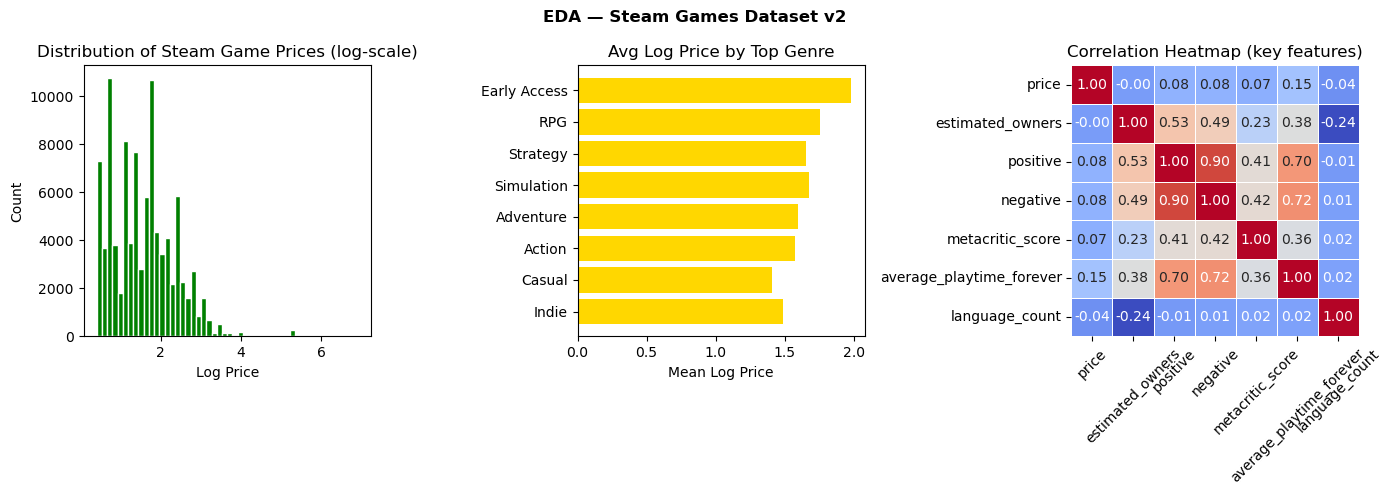

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("EDA — Steam Games Dataset v2", fontweight='bold')

# Plot 1 - Price Distribution
axes[0].hist(steam['price'], bins=50, color="green", edgecolor="white")
axes[0].set_title("Distribution of Steam Game Prices (log-scale)")
axes[0].set_xlabel("Log Price")
axes[0].set_ylabel("Count")

# Plot 2 - Avg Price by Genre
top_genres = steam[genre_cols].sum().sort_values(ascending=False).head(8).index.tolist()
genre_names = []
genre_avg_prices = []
for g in top_genres:
    genre_names.append(g.replace("genre_", ""))
    genre_avg_prices.append(steam[steam[g] == 1]['price'].mean())

axes[1].barh(genre_names, genre_avg_prices, color='gold')
axes[1].set_title("Avg Log Price by Top Genre")
axes[1].set_xlabel("Mean Log Price")

# Plot 3 - Corr heatmap
sns.heatmap(corr, ax=axes[2], annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, cbar=False)
axes[2].set_title("Correlation Heatmap (key features)")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()